# Project 2

In addition to answering the bolded questions on Canvas, complete the Python work in this notebook.

This version uses a **local autograder** and a **Gradescope `.py` submission**. The 10 graded coding checkpoints are worth **2 points each (20 points total)**.

## Python submission
At the end of the notebook, run the **Export Gradescope Submission** cell. It creates a standalone file named `project2_submission.py`, verifies that Python can import it, and (in Google Colab) downloads it automatically.

**Submit `project2_submission.py` to Gradescope.** The exported file contains only the 10 graded functions; plotting cells, dataset-loading cells, and local-grading code are intentionally excluded.

> Keep every function definition syntactically valid while you work. Replace `raise NotImplementedError` with your implementation when you complete a function.


## Getting Setup
Run the imports and local-autograder setup cells below. `College.csv` should be in the same working directory as the notebook.


In [1]:
# Core imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Notebook-friendly equivalent of %matplotlib inline that remains valid Python
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)


Python: 3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
Pandas: 3.0.2
Seaborn: 0.13.2


In [2]:
# -----------------------------------------------------------------------------
# Local autograder
# -----------------------------------------------------------------------------
_GRADING_POINTS = {
    "large_university_bin_test": 2,
    "enroll_test": 2,
    "acceptance_rate_test": 2,
    "highest_pop_test": 2,
    "lowest_med_inc_test": 2,
    "highest_ave_occup_test": 2,
    "bay_area_test": 2,
    "med_rooms_test": 2,
    "min_val_test": 2,
    "num_districts_test": 2,
}
_GRADING_RESULTS = {}


def _record_local_result(test_id, passed, message=""):
    points = _GRADING_POINTS[test_id]
    earned = points if passed else 0
    _GRADING_RESULTS[test_id] = earned
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {test_id}: {earned}/{points}")
    if message:
        print(message)
    return passed


def _scalar_close(actual, expected):
    try:
        return bool(np.isclose(actual, expected, rtol=1e-10, atol=1e-10, equal_nan=True))
    except Exception:
        return False


def grade_large_university_bin(answer, source_df):
    try:
        expected = (source_df["Enroll"] > source_df["Enroll"].mean()).tolist()
        actual = list(answer)
        if actual != expected:
            raise AssertionError("The mask does not match Enroll > mean(Enroll).")
        return _record_local_result("large_university_bin_test", True)
    except Exception as exc:
        return _record_local_result("large_university_bin_test", False, f"{type(exc).__name__}: {exc}")


def grade_enroll(answer, source_df):
    try:
        mask = source_df["Enroll"] > source_df["Enroll"].mean()
        expected = source_df.loc[mask, "Enroll"].quantile(0.75)
        if not _scalar_close(answer, expected):
            raise AssertionError(f"Expected {expected!r}, got {answer!r}.")
        return _record_local_result("enroll_test", True)
    except Exception as exc:
        return _record_local_result("enroll_test", False, f"{type(exc).__name__}: {exc}")


def grade_acceptance_rate(answer, source_df):
    try:
        expected = source_df["Accept"] / source_df["Apps"]
        if not isinstance(answer, pd.Series):
            raise AssertionError(f"Expected a pandas Series, got {type(answer).__name__}.")
        pd.testing.assert_series_equal(answer, expected, check_dtype=False, check_names=False)
        return _record_local_result("acceptance_rate_test", True)
    except Exception as exc:
        return _record_local_result("acceptance_rate_test", False, f"{type(exc).__name__}: {exc}")


def grade_highest_pop(answer, source_df):
    try:
        expected = source_df["Population"].idxmax()
        if answer != expected:
            raise AssertionError(f"Expected index {expected!r}, got {answer!r}.")
        return _record_local_result("highest_pop_test", True)
    except Exception as exc:
        return _record_local_result("highest_pop_test", False, f"{type(exc).__name__}: {exc}")


def grade_lowest_med_inc(answer, source_df):
    try:
        expected = source_df["MedInc"].idxmin()
        if answer != expected:
            raise AssertionError(f"Expected index {expected!r}, got {answer!r}.")
        return _record_local_result("lowest_med_inc_test", True)
    except Exception as exc:
        return _record_local_result("lowest_med_inc_test", False, f"{type(exc).__name__}: {exc}")


def grade_highest_ave_occup(answer, source_df):
    try:
        expected = source_df["AveOccup"].idxmax()
        if answer != expected:
            raise AssertionError(f"Expected index {expected!r}, got {answer!r}.")
        return _record_local_result("highest_ave_occup_test", True)
    except Exception as exc:
        return _record_local_result("highest_ave_occup_test", False, f"{type(exc).__name__}: {exc}")


def grade_bay_area(answer, source_df):
    try:
        expected = source_df[
            source_df["Latitude"].between(37, 38, inclusive="both")
            & source_df["Longitude"].between(-122, -121, inclusive="both")
        ].shape[0]
        if int(answer) != int(expected):
            raise AssertionError(f"Expected {expected}, got {answer!r}.")
        return _record_local_result("bay_area_test", True)
    except Exception as exc:
        return _record_local_result("bay_area_test", False, f"{type(exc).__name__}: {exc}")


def grade_med_rooms(answer, source_df):
    try:
        expected = source_df.loc[source_df["MedInc"] > 5, "AveRooms"].median()
        if not _scalar_close(answer, expected):
            raise AssertionError(f"Expected {expected!r}, got {answer!r}.")
        return _record_local_result("med_rooms_test", True)
    except Exception as exc:
        return _record_local_result("med_rooms_test", False, f"{type(exc).__name__}: {exc}")


def grade_min_val(answer, source_df):
    try:
        median_income = source_df["MedInc"].median()
        expected = source_df.loc[source_df["MedInc"] > median_income, "MedHouseVal"].idxmin()
        if answer != expected:
            raise AssertionError(f"Expected index {expected!r}, got {answer!r}.")
        return _record_local_result("min_val_test", True)
    except Exception as exc:
        return _record_local_result("min_val_test", False, f"{type(exc).__name__}: {exc}")


def grade_num_districts(answer, source_df):
    try:
        median_rooms = source_df["AveRooms"].median()
        median_house = source_df["MedHouseVal"].median()
        expected = source_df[
            (source_df["AveRooms"] > median_rooms)
            & (source_df["MedHouseVal"] > median_house)
        ].shape[0]
        if int(answer) != int(expected):
            raise AssertionError(f"Expected {expected}, got {answer!r}.")
        return _record_local_result("num_districts_test", True)
    except Exception as exc:
        return _record_local_result("num_districts_test", False, f"{type(exc).__name__}: {exc}")


def show_grading_summary():
    earned = sum(_GRADING_RESULTS.values())
    total = sum(_GRADING_POINTS.values())
    print(f"Local grading score: {earned}/{total}")
    not_run = [name for name in _GRADING_POINTS if name not in _GRADING_RESULTS]
    if not_run:
        print("Not yet run:", ", ".join(not_run))
    return earned, total


## Part A

First, we return to the College dataset. This dataset contains information from 777 U.S. universities and colleges.


In [3]:
college = pd.read_csv("College.csv").copy()
college = college.rename(columns={
    "Grad.Rate": "Grad_Rate",
    "S.F.Ratio": "S_F_Ratio",
    "perc.alumni": "perc_alumni",
    "Room.Board": "Room_Board",
    "F.Undergrad": "F_Undergrad",
    "P.Undergrad": "P_Undergrad",
})
college.set_index("Names", inplace=True)
college.head()


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
Names,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### 1. Pairplot
Use `seaborn.pairplot()` on the original dataframe to produce a scatterplot matrix of the first ten columns. Comment on your observations.


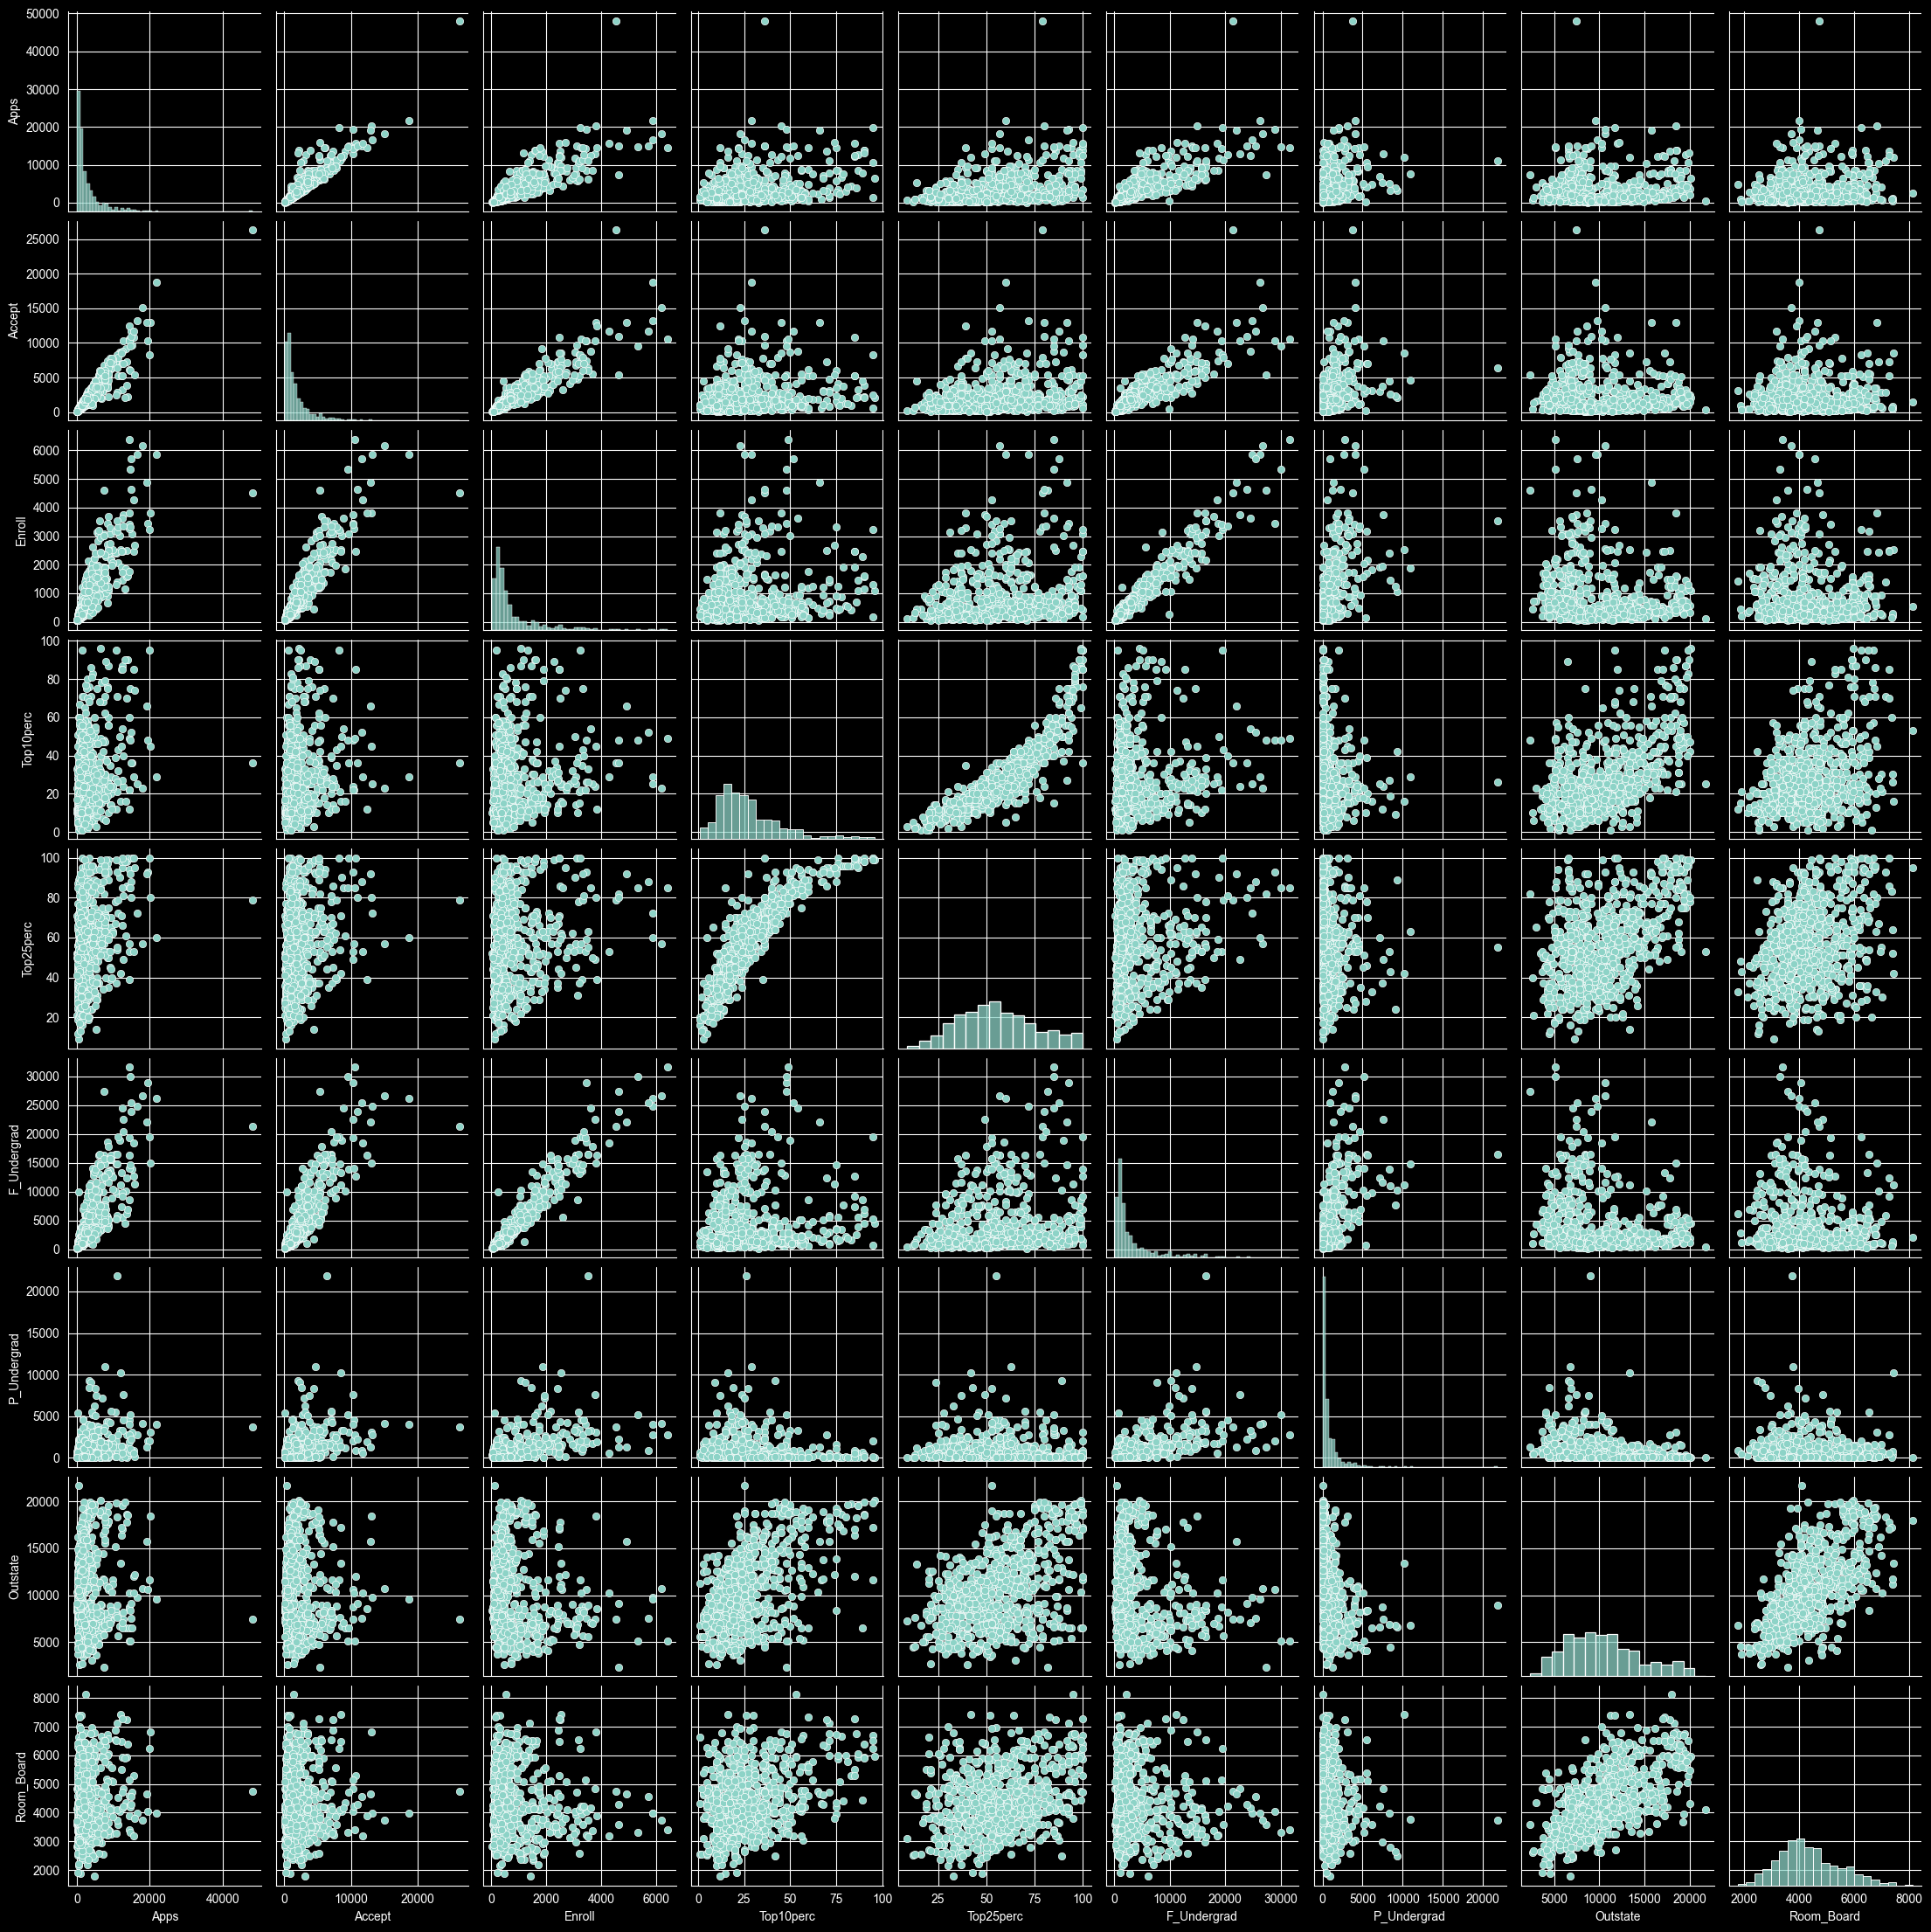

In [4]:
sns.pairplot(college.iloc[:, :10])

### 2. Out-of-state tuition by private/public status
Use `seaborn.boxplot()` to produce side-by-side box plots of `Outstate` versus `Private`. **Answer on Canvas: On average, are private universities more expensive than public universities?**


<Axes: xlabel='Private', ylabel='Outstate'>

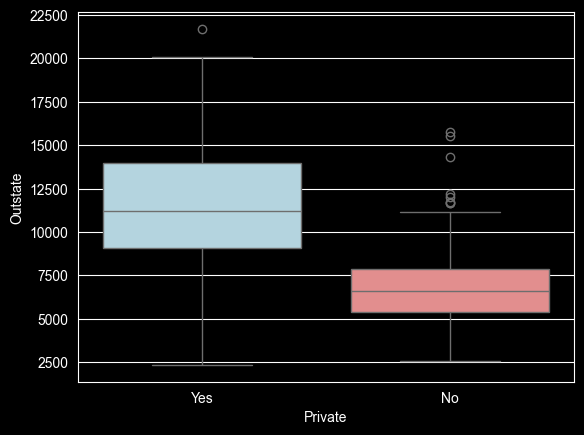

In [5]:
sns.boxplot(x="Private", y="Outstate", data=college, palette=["lightblue", "lightcoral"], hue="Private", legend=False)


### 3. Create the `large_university` mask — 2 points
A university is considered large when its `Enroll` value is **greater than the mean enrollment** of all universities. Implement `create_large_university_mask(df)` and assign its result to `large_university`.


In [6]:
def create_large_university_mask(df):
    return df["Enroll"] > df["Enroll"].mean()

large_university = create_large_university_mask(college)
large_university.head()


Names
Abilene Christian University    False
Adelphi University              False
Adrian College                  False
Agnes Scott College             False
Alaska Pacific University       False
Name: Enroll, dtype: bool

In [7]:
grade_large_university_bin(large_university, college)


[PASS] large_university_bin_test: 2/2


True

### 4. Create `large_universities`
Create a dataframe named `large_universities` containing only rows where `large_university` is `True`.


In [8]:
# Assign your filtered DataFrame to large_universities.
large_universities = college[large_university]
large_universities.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
Names,,,,,,,,,,,,,,,,,,
Angelo State University,No,3540,2001,1016,24,54,4190,1512,5130,3592,500,2000,60,62,23.1,5,4010,34
Appalachian State University,No,7313,4664,1910,20,63,9940,1035,6806,2540,96,2000,83,96,18.3,14,5854,70
Arizona State University Main campus,No,12809,10308,3761,24,49,22593,7585,7434,4850,700,2100,88,93,18.9,5,4602,48
Arkansas Tech University,No,1734,1729,951,12,52,3602,939,3460,2650,450,1000,57,60,19.6,5,4739,48
Auburn University-Main Campus,No,7548,6791,3070,25,57,16262,1716,6300,3933,600,1908,85,91,16.7,18,6642,69


### 5. 75th percentile enrollment among large universities — 2 points
Use `describe(include="all")` if helpful. Implement `get_large_university_enroll_75th_percentile(df)` so it returns the 75th percentile of `Enroll` among universities whose enrollment exceeds the overall mean. Name the result `enroll_answer`. **Enter this answer on Canvas.**


In [48]:
def get_large_university_enroll_75th_percentile(df):
    return df[df["Enroll"] > df["Enroll"].mean()].describe(include="all")["Enroll"]["75%"]

enroll_answer = get_large_university_enroll_75th_percentile(college)
print(enroll_answer)


2408.0


In [49]:
grade_enroll(enroll_answer, college)


[PASS] enroll_test: 2/2


True

### 6. Tuition by university size
Use a boxplot to determine whether larger universities are more expensive. **Answer on Canvas: On average, are large universities more expensive than small universities?**


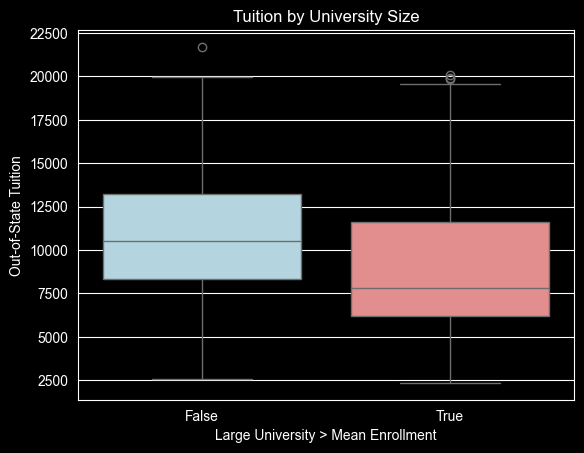

In [11]:
sns.boxplot(x=large_university, y=college["Outstate"], palette=["lightblue", "lightcoral"], hue=large_university, legend=False)
plt.xlabel("Large University > Mean Enrollment")
plt.ylabel("Out-of-State Tuition")
plt.title("Tuition by University Size")
plt.show()


### 7. Enrollment versus out-of-state tuition
Plot enrollment size against out-of-state tuition. **Answer on Canvas: What type of relationship does this show (weak, medium, strong)?**


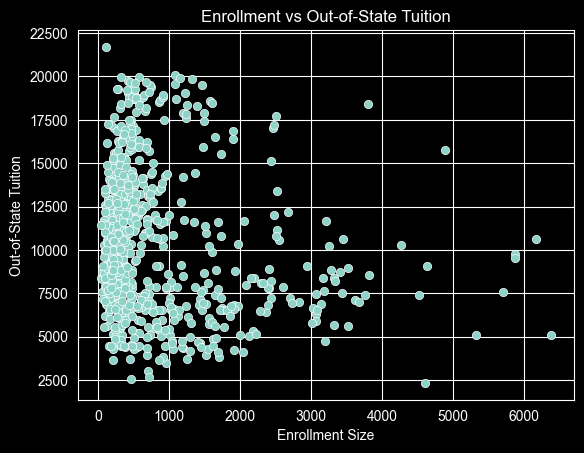

In [12]:
sns.scatterplot(x="Enroll", y="Outstate", data=college)
plt.xlabel("Enrollment Size")
plt.ylabel("Out-of-State Tuition")
plt.title("Enrollment vs Out-of-State Tuition")
plt.show()

### 8. Histograms
Create histograms with different numbers of bins for quantitative variables. In particular, make a histogram of `Apps` using 200 bins. **Answer on Canvas: Are there more universities that receive 0–10,000 applications or 10,000–20,000 applications?**


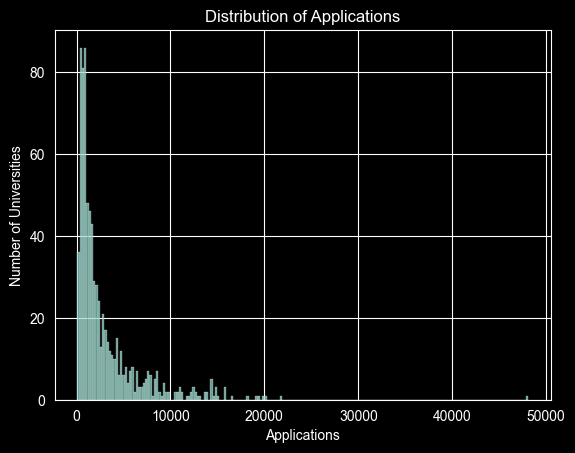

In [13]:
sns.histplot(college["Apps"], bins=200)

plt.xlabel("Applications")
plt.ylabel("Number of Universities")
plt.title("Distribution of Applications")
plt.show()


### 9. Acceptance rate — 2 points
Acceptance rate is `Accept / Apps`. Implement `calculate_acceptance_rate(df)`. Then add the returned Series to a **copied** dataframe as `Acceptance_Rate`. **Answer on Canvas: Is the relationship between acceptance rate and `Top10perc` positive or negative?**


In [14]:
def calculate_acceptance_rate(df):
    return df["Accept"] / df["Apps"]

acceptance_rate = calculate_acceptance_rate(college)
college_new = college.copy()
college_new["Acceptance_Rate"] = acceptance_rate
college_new.head()


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate,Acceptance_Rate
Names,,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,0.742169
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,0.880146
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,0.768207
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,0.836930
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,0.756477


In [15]:
grade_acceptance_rate(acceptance_rate, college)


[PASS] acceptance_rate_test: 2/2


True

You may plot `Acceptance_Rate` versus `Top10perc` to help answer the Canvas question.



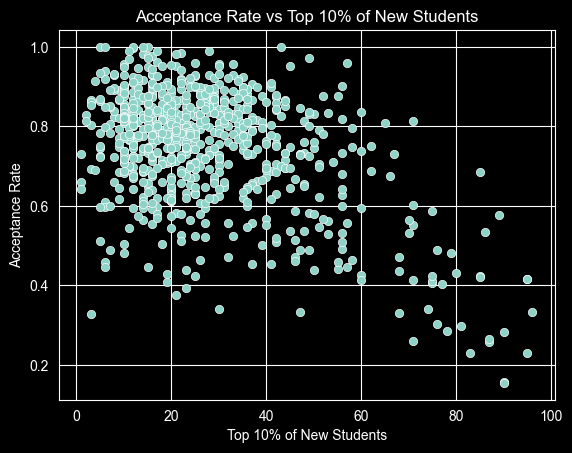

In [16]:
sns.scatterplot(x="Top10perc", y="Acceptance_Rate", data=college_new)
plt.xlabel("Top 10% of New Students")
plt.ylabel("Acceptance Rate")
plt.title("Acceptance Rate vs Top 10% of New Students")
plt.show()


### 10. Continue exploring
Continue exploring the College data and provide a brief summary of what you discover.


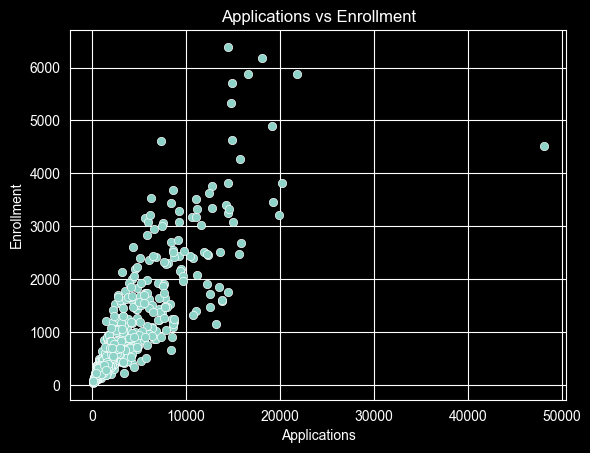

In [17]:
sns.scatterplot(x=college["Apps"], y=college["Enroll"])

plt.xlabel("Applications")
plt.ylabel("Enrollment")
plt.title("Applications vs Enrollment")
plt.show()



## Part B

Next, use the California housing dataset, which contains district-level variables from the 1990 California census.


### 1. Load the California housing dataset


In [18]:
%pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from sklearn.datasets import fetch_california_housing
california_dataset = fetch_california_housing()
california = pd.DataFrame(data=california_dataset.data, columns=california_dataset.feature_names)
california["MedHouseVal"] = pd.Series(california_dataset.target)
california.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2. Pairwise scatterplots
Make pairwise scatterplots of some predictors. Avoid plotting every predictor if runtime becomes excessive. Comment on your observations.


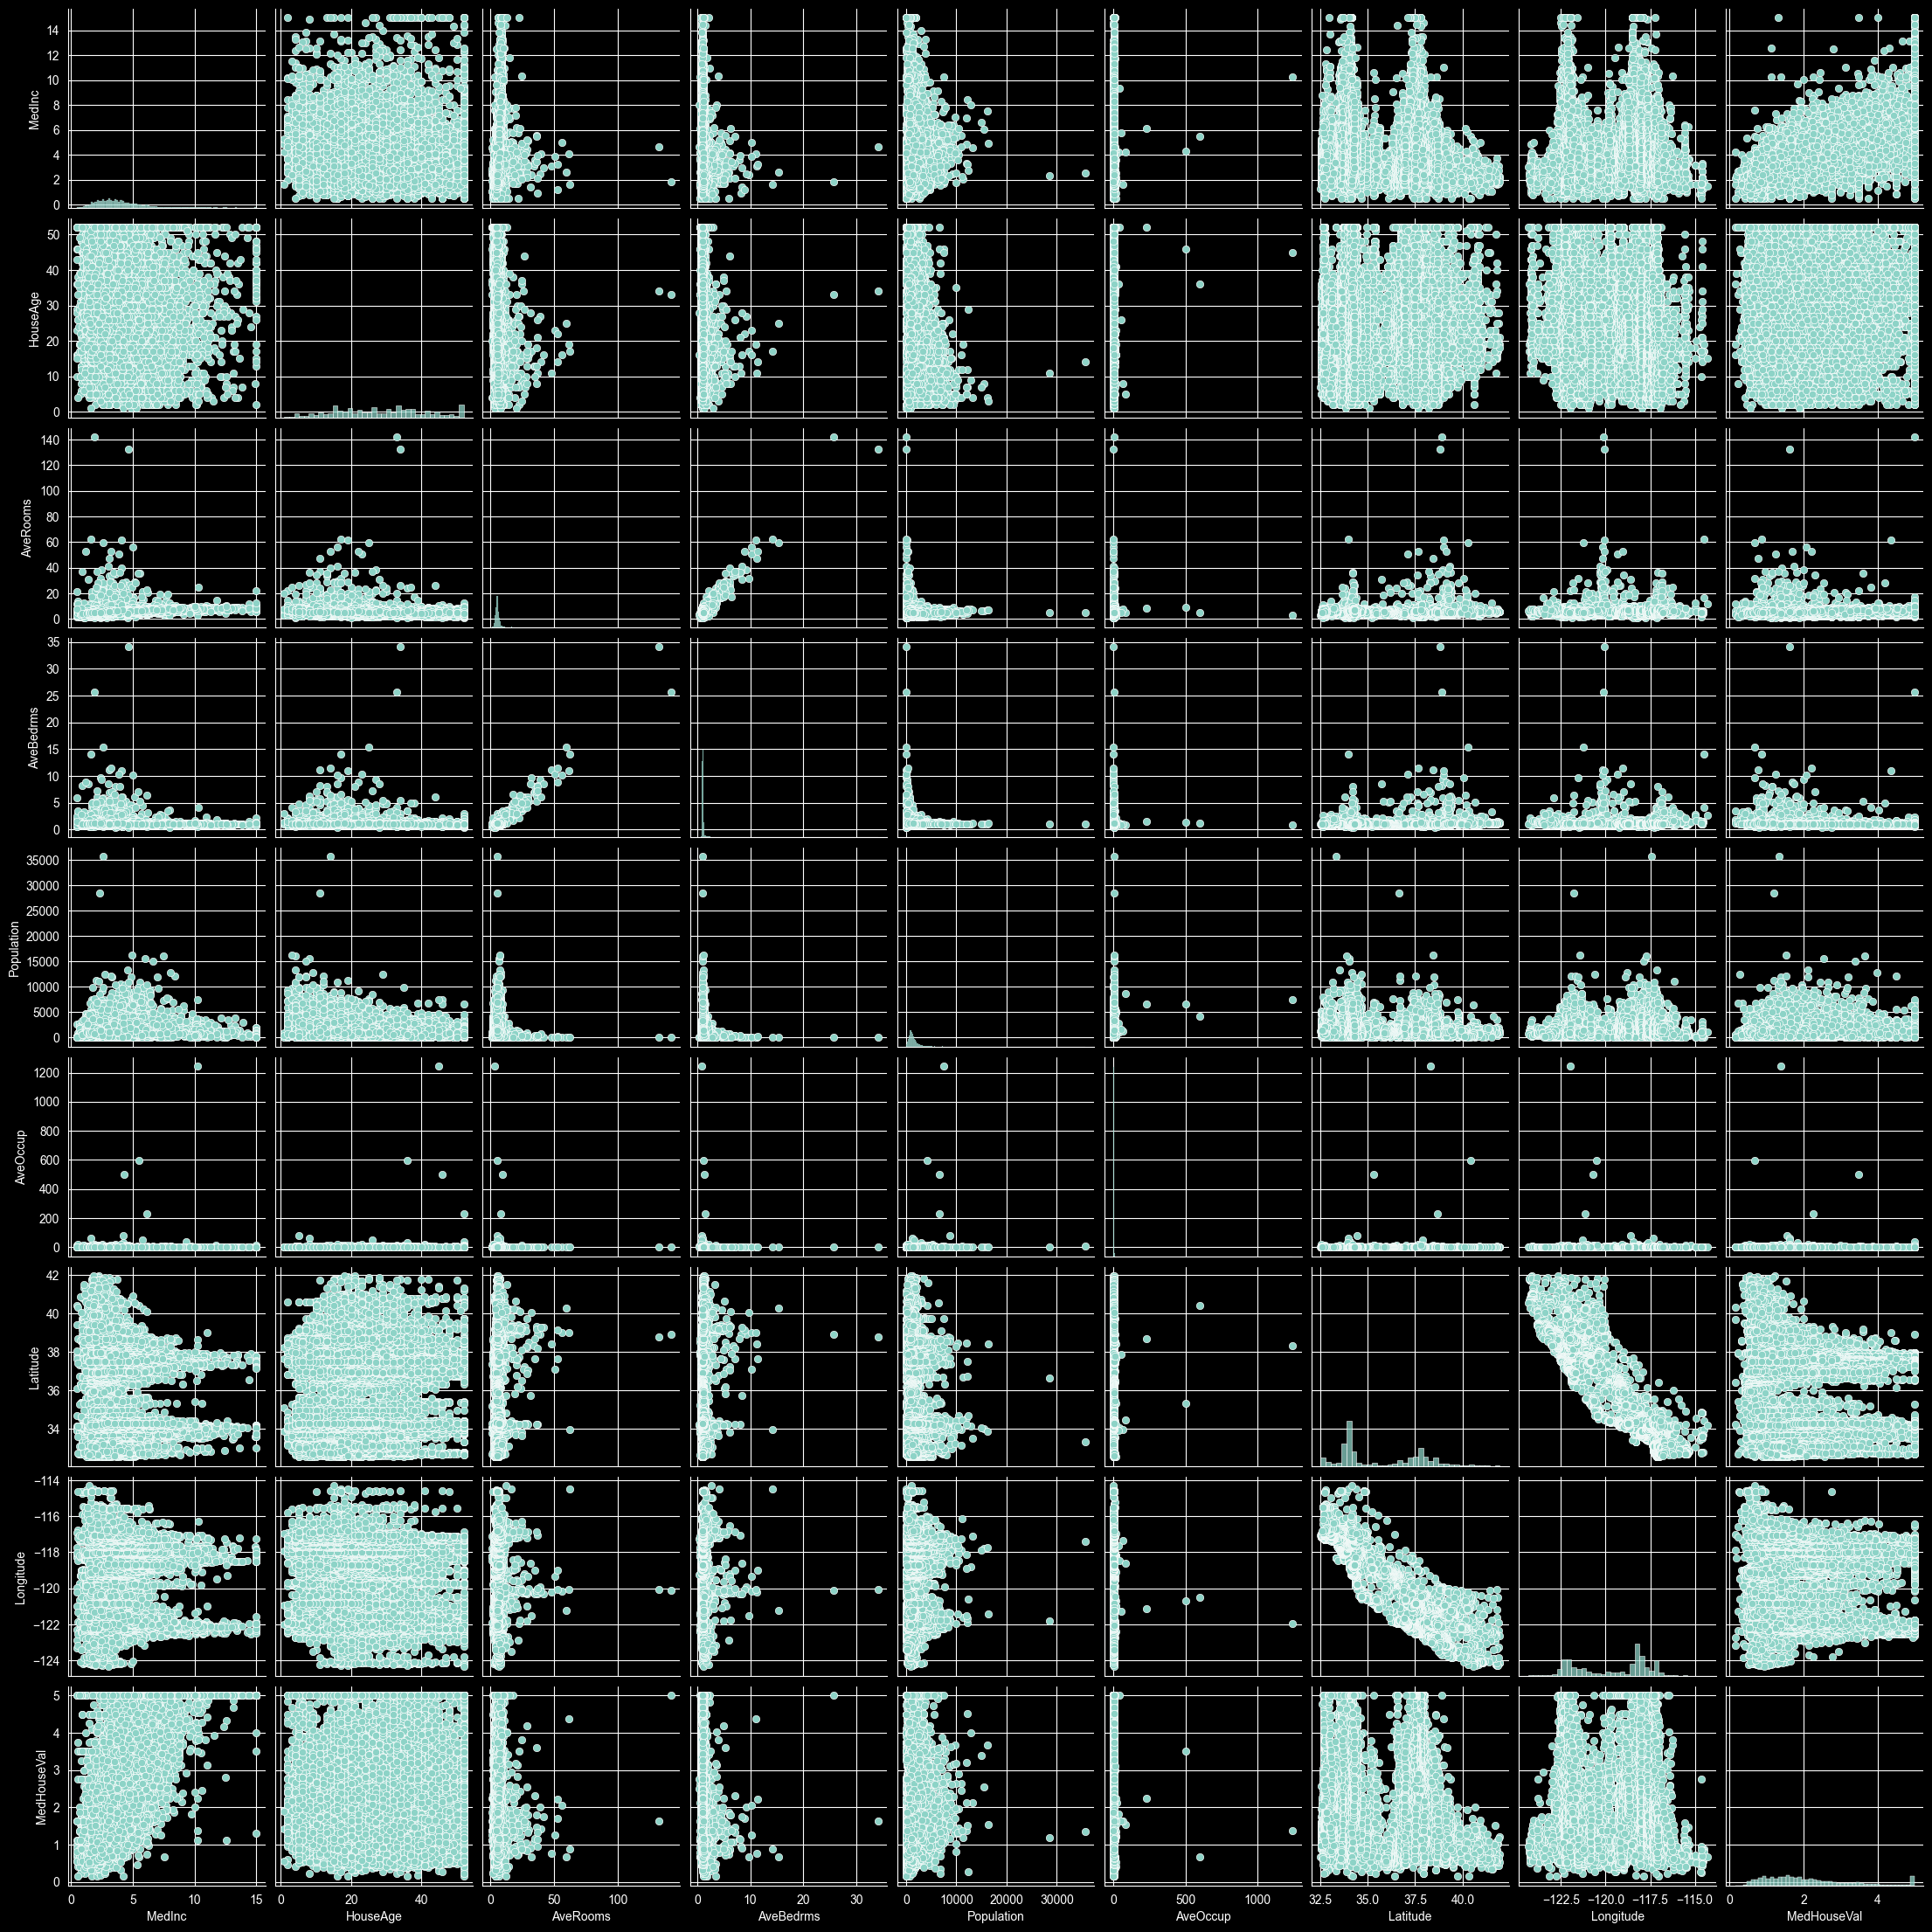

In [20]:
sns.pairplot(california)


### 3. Correlations
Examine correlations with `MedHouseVal`. **Answer on Canvas: Which predictor has the highest correlation with `MedHouseVal`, excluding `MedHouseVal` itself?**


In [21]:
california.corr()["MedHouseVal"].sort_values(ascending=False).index[1]


'MedInc'

### 4. Extreme districts — 6 points total
Implement the following three functions. If multiple districts tie for an extreme value, return the **first index** (the behavior of `idxmax()` / `idxmin()`).


In [22]:
def get_highest_population_index(df):
    return df["Population"].idxmax()

highest_pop = get_highest_population_index(california)
print(highest_pop)


15360


In [23]:
grade_highest_pop(highest_pop, california)


[PASS] highest_pop_test: 2/2


True

In [24]:
def get_lowest_median_income_index(df):
    return df["MedInc"].idxmin()

lowest_med_inc = get_lowest_median_income_index(california)
print(lowest_med_inc)


73


In [25]:
grade_lowest_med_inc(lowest_med_inc, california)


[PASS] lowest_med_inc_test: 2/2


True

In [26]:
def get_highest_average_occupancy_index(df):
    return df["AveOccup"].idxmax()
highest_ave_occup = get_highest_average_occupancy_index(california)
print(highest_ave_occup)


19006


In [27]:
grade_highest_ave_occup(highest_ave_occup, california)


[PASS] highest_ave_occup_test: 2/2


True

### 5. San Francisco Bay Area count — 2 points
Count districts with latitude from **37 through 38 inclusive** and longitude from **-122 through -121 inclusive**. Implement `count_bay_area_districts(df)` and name the result `bay_area`. **Enter the result on Canvas.**


In [28]:
def count_bay_area_districts(df):
    bay_area_mask = df["Latitude"].between(37, 38, inclusive="both") & df["Longitude"].between(-122, -121, inclusive="both")
    return bay_area_mask.sum()


bay_area = count_bay_area_districts(california)
print(bay_area)


1392


In [29]:
grade_bay_area(bay_area, california)


[PASS] bay_area_test: 2/2


True

### 6. Median rooms among higher-income districts — 2 points
Among districts with `MedInc > 5`, compute the median `AveRooms`. Implement `get_median_rooms_for_high_income(df)` and name the result `med_rooms`. **Enter the result on Canvas.**


In [30]:
def get_median_rooms_for_high_income(df):
    high_income_mask = df["MedInc"] > 5
    return df.loc[high_income_mask, "AveRooms"].median()

med_rooms = get_median_rooms_for_high_income(california)
print(med_rooms)


6.50625


In [31]:
grade_med_rooms(med_rooms, california)


[PASS] med_rooms_test: 2/2


True

### 7. Lowest house value above median income — 2 points
Among districts whose `MedInc` is greater than the overall median income, find the index of the district with the lowest `MedHouseVal`. Implement `get_min_house_value_index_above_median_income(df)` and name the result `min_val`. If tied, choose the first observation. **Enter the result on Canvas.** Then inspect the other predictors for that district and comment on them.


In [32]:
def get_min_house_value_index_above_median_income(df):
    median_income = df["MedInc"].median()
    filtered_df = df[df["MedInc"] > median_income]
    return filtered_df["MedHouseVal"].idxmin()

min_val = get_min_house_value_index_above_median_income(california)
print(min_val)
california.loc[[min_val]]


9188


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
9188,4.1932,52.0,3.568889,1.186667,628.0,2.791111,34.24,-117.86,0.14999


In [33]:
grade_min_val(min_val, california)


[PASS] min_val_test: 2/2


True

### 8. Districts above both medians — 2 points
Compute the overall medians of `AveRooms` and `MedHouseVal`, then count districts where **both** values are strictly greater than their corresponding medians. Implement `count_districts_above_median_rooms_and_value(df)` and name the result `num_districts`.


In [34]:
def count_districts_above_median_rooms_and_value(df):
    median_rooms = df["AveRooms"].median()
    median_house_value = df["MedHouseVal"].median()
    mask = (df["AveRooms"] > median_rooms) & (df["MedHouseVal"] > median_house_value)
    return mask.sum()
num_districts = count_districts_above_median_rooms_and_value(california)
print(num_districts)


6120


In [35]:
grade_num_districts(num_districts, california)


[PASS] num_districts_test: 2/2


True

### Other observations
What other observations can you make from the California housing dataset?


In [ ]:
# YOUR CODE HERE
raise NotImplementedError


## Local grading summary
Run this after you have run all 10 grading cells above.


In [38]:
show_grading_summary()


Local grading score: 20/20


(20, 20)

## Export Gradescope Submission

After completing the assignment, run **all cells that define the 10 graded functions**, then run the export cell below.

It creates **`project2_submission.py`**, syntax-checks it, and downloads it automatically in Google Colab. Upload that generated file to Gradescope.

The Gradescope grader also accepts a single full notebook-converted `.py` file when it is valid Python, but the clean exporter is the recommended path.


In [39]:
# Export the student's graded functions as a clean, standalone Python module.
import ast
import subprocess
import sys
from pathlib import Path

REQUIRED_SUBMISSION_FUNCTIONS = [
    "create_large_university_mask",
    "get_large_university_enroll_75th_percentile",
    "calculate_acceptance_rate",
    "get_highest_population_index",
    "get_lowest_median_income_index",
    "get_highest_average_occupancy_index",
    "count_bay_area_districts",
    "get_median_rooms_for_high_income",
    "get_min_house_value_index_above_median_income",
    "count_districts_above_median_rooms_and_value",
]


def _latest_function_sources_from_history(function_names):
    """Find the latest notebook definition of each required function."""
    wanted = set(function_names)
    found = {}

    ip = get_ipython()
    history = ip.history_manager.input_hist_raw

    for cell_source in history:
        if not cell_source or not isinstance(cell_source, str):
            continue
        try:
            tree = ast.parse(cell_source)
        except SyntaxError:
            # Ignore notebook-only cells or cells that were incomplete when executed.
            continue

        for node in tree.body:
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.name in wanted:
                source = ast.get_source_segment(cell_source, node)
                if source is None:
                    source = ast.unparse(node)
                found[node.name] = source.strip()

    return found


def export_gradescope_submission(filename="project2_submission.py", download=True):
    """Create the clean .py file that students should upload to Gradescope."""
    sources = _latest_function_sources_from_history(REQUIRED_SUBMISSION_FUNCTIONS)
    missing = [name for name in REQUIRED_SUBMISSION_FUNCTIONS if name not in sources]
    if missing:
        raise RuntimeError(
            "Cannot export yet. Run the cells that define these functions, then rerun this cell: "
            + ", ".join(missing)
        )

    header = '''"""Project 2 Gradescope submission.

Generated from the Project 2 notebook. This module intentionally contains no
notebook magics, plotting cells, local-grading calls, or dataset downloads.
"""

import numpy as np
import pandas as pd

'''

    body = "\n\n\n".join(sources[name] for name in REQUIRED_SUBMISSION_FUNCTIONS)
    submission_source = header + body + "\n"

    # Validate syntax before writing/downloading.
    ast.parse(submission_source, filename=filename)

    output_path = Path(filename).resolve()
    output_path.write_text(submission_source, encoding="utf-8")

    subprocess.run(
        [sys.executable, "-m", "py_compile", str(output_path)],
        check=True,
        capture_output=True,
        text=True,
    )

    print(f"Created and verified: {output_path}")
    print("Upload THIS file to Gradescope.")

    if download:
        try:
            from google.colab import files
            files.download(str(output_path))
        except ImportError:
            print("Automatic download is only available in Google Colab.")

    return output_path


In [50]:
export_gradescope_submission()

Created and verified: /Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_2/project2_submission.py
Upload THIS file to Gradescope.
Automatic download is only available in Google Colab.


PosixPath('/Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_2/project2_submission.py')